In [1]:
!pip install pennylane
!pip install qiskit
!pip install qiskit-machine-learning
!pip install qiskit-ibm-runtime


In [2]:
pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [24]:
!python -m pip uninstall -y qiskit qiskit-aer qiskit-aer-gpu qiskit-aer-gpu-cu11 qiskit-terra
!python -m pip cache purge
!python -m pip install --upgrade pip
!python -m pip install qiskit==2.3.0 qiskit-aer

Found existing installation: qiskit 2.3.0
Uninstalling qiskit-2.3.0:
  Successfully uninstalled qiskit-2.3.0
Found existing installation: qiskit-aer 0.15.1
Uninstalling qiskit-aer-0.15.1:
  Successfully uninstalled qiskit-aer-0.15.1
Files removed: 1196
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 16.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [qiskit-aer]2 [qiskit-aer]


In [4]:
pip install dwave-ocean-sdk

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pylatexenc
import matplotlib
import qiskit
from qiskit import *

In [6]:
qiskit.__version__

'2.3.0'

In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel = 'ibm_quantum_platform', token = "REMOVED")

qiskit_runtime_service._discover_account:WARNING:2026-03-10 15:30:39,263: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-10 15:30:43,524: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [8]:
qc = QuantumCircuit(3,3)
qc.draw()

q_0: 
     
q_1: 
     
q_2: 
     
c: 3/

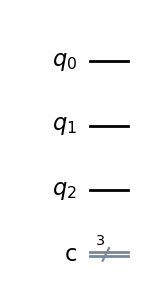

In [9]:
qc.draw('mpl')

In [10]:
qc.measure([0,1,2], [0,1,2])
qc.draw()

┌─┐      
q_0: ┤M├──────
     └╥┘┌─┐   
q_1: ─╫─┤M├───
      ║ └╥┘┌─┐
q_2: ─╫──╫─┤M├
      ║  ║ └╥┘
c: 3/═╩══╩══╩═
      0  1  2

In [11]:
qreg1 = QuantumRegister(size = 2, name = "qrg1")
qreg2 = QuantumRegister(size = 1, name = "qrg2")
creg = ClassicalRegister(1, "oldschool")

In [12]:
qc1 = QuantumCircuit(qreg1, creg, qreg2)
qc1.draw()

qrg1_0: 
             
     qrg1_1: 
             
       qrg2: 
             
oldschool: 1/

In [13]:
qc1.draw()

qrg1_0: 
             
     qrg1_1: 
             
       qrg2: 
             
oldschool: 1/

In [14]:
# QUANTUM GATES
# por defecto todos los qubits se inicializan al estado |0>

In [15]:
qc.x(0)
# aplicar una puerta X al primer quibit. Indexado habitual en Python (comienza en 0)

In [16]:
qc.draw()

┌─┐┌───┐   
q_0: ┤M├┤ X ├───
     └╥┘└┬─┬┘   
q_1: ─╫──┤M├────
      ║  └╥┘ ┌─┐
q_2: ─╫───╫──┤M├
      ║   ║  └╥┘
c: 3/═╩═══╩═══╩═
      0   1   2

In [17]:
qc = QuantumCircuit(2,2)
qc.draw()

q_0: 
     
q_1: 
     
c: 2/

In [18]:
qc.x(0)
qc.h(1)
qc.cx(0,1)
qc.measure([0,1],[0,1])
qc.draw()

┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     ├───┤┌─┴─┐└╥┘┌─┐
q_1: ┤ H ├┤ X ├─╫─┤M├
     └───┘└───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

In [19]:
# CUANDO SE EJECUTA UN BLQUE DE CODIGO SIN LA SEMILLA DEL CIRCUITO, SE AÑADE A LO ANTERIOR -> 
# SE PUEDE GENERAR UN CIRCUITO QUE NO ES EL QUE SE BUSCA, MÁS COMPONENTES DE LO NECESARIO

In [20]:
# HELLO WORLD EXAMPLO ON A TWO QUBIT BELL STATE

In [21]:
hqc = QuantumCircuit(2)
hqc.h(0)
hqc.cx(0,1)
hqc.measure_all()
hqc.draw()

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

In [22]:
from qiskit.quantum_info import Pauli

ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')

observables = [ZZ, ZI, IZ, XX, XI, IX]

In [23]:
#EJECUTAR EN EL BACKEND

from qiskit_aer import AerSimulator
sim = AerSimulator()
compiled = transpile(hqc,sim)
job = sim.run(compiled, shots = 1024)
result = job.result()
counts = result.get_counts()

ImportError: cannot import name 'convert_to_target' from 'qiskit.providers' (/opt/miniconda3/lib/python3.12/site-packages/qiskit/providers/__init__.py)